In [18]:
import torch.multiprocessing as mp
import numpy as np
from multiprocessing import Pool, Manager
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed
from threading import Lock
from tqdm import tqdm
import gym
import time
import copy
import flexible_bus
import json
import os
from functools import partial
import queue
from Behaviour_pi import Behavioural, Policy
from src_Hi_CoLA_v2 import Hi_CoLA_Net, HiCoLAWithScaler
import src_Hi_CoLA_v2 as hc

import pandas as pd
import torch.nn as nn
from Simulation import traj_collect
from src_utils import *
from src_clb_cal_v2 import *

traj_list = pd.read_parquet("./exp_multi_epochs/changed_object2/trajectories_optimized.pq")
traj_list

,trajectory_id,return,obs_0,action_0,direct_action_0,obs_1,action_1,direct_action_1,obs_2,action_2,direct_action_2,obs_3,action_3,direct_action_3,obs_4,action_4,direct_action_4
0,0,287,"[3, 11, 19, 9, 21]","[0.6359288096427917, 0.5670178532600403]","[1, 1]","[2, 5, 18, 7, 16]","[0.6265698671340942, 0.5522294044494629]","[0, 1]","[1, 10, 17, 6, 17]","[0.6322453618049622, 0.5613199472427368]","[0, 1]","[3, 6, 22, 15, 26]","[0.633699357509613, 0.5635682344436646]","[1, 1]","[4, 8, 21, 14, 21]","[0.6266926527023315, 0.5398903489112854]","[1, 1]"
1,1,270,"[2, 4, 19, 8, 33]","[0.6778690814971924, 0.6272721290588379]","[1, 1]","[1, 4, 31, 10, 19]","[0.6304925680160522, 0.5506314039230347]","[0, 0]","[0, 5, 21, 8, 21]","[0.6420060992240906, 0.5719073414802551]","[0, 0]","[2, 14, 30, 5, 22]","[0.6500988006591797, 0.5889943242073059]","[1, 1]","[3, 11, 14, 4, 21]","[0.6470492482185364, 0.5880267024040222]","[0, 0]"
2,2,240,"[1, 8, 20, 8, 19]","[0.6327115893363953, 0.561759889125824]","[0, 1]","[1, 9, 15, 12, 25]","[0.6391667723655701, 0.5720174312591553]","[0, 0]","[0, 9, 20, 7, 21]","[0.6434904932975769, 0.5759648084640503]","[1, 0]","[2, 7, 19, 12, 17]","[0.621640682220459, 0.5310782790184021]","[1, 1]","[3, 7, 17, 8, 16]","[0.623936116695404, 0.5479084849357605]","[0, 1]"
3,3,271,"[2, 6, 22, 7, 19]","[0.6354702115058899, 0.5663080811500549]","[1, 1]","[1, 11, 19, 9, 20]","[0.6326485276222229, 0.5619432330131531]","[1, 0]","[4, 6, 34, 7, 15]","[0.626305103302002, 0.5434065461158752]","[0, 1]","[2, 14, 15, 11, 22]","[0.6081723570823669, 0.5504881143569946]","[1, 0]","[2, 6, 20, 8, 15]","[0.6210010051727295, 0.5426409840583801]","[1, 1]"
4,4,256,"[5, 5, 15, 4, 26]","[0.6651665568351746, 0.6124227046966553]","[0, 1]","[1, 8, 19, 12, 15]","[0.6187400817871094, 0.5230408310890198]","[0, 1]","[3, 9, 27, 7, 13]","[0.6216007471084595, 0.5339791178703308]","[1, 1]","[5, 8, 17, 10, 14]","[0.6186583638191223, 0.5270723700523376]","[1, 0]","[3, 6, 20, 5, 22]","[0.6503170132637024, 0.5893332362174988]","[1, 1]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9994,3328,235,"[3, 8, 10, 6, 16]","[0.6222096681594849, 0.5542123317718506]","[0, 1]","[2, 13, 22, 9, 22]","[0.6387887001037598, 0.5714464783668518]","[0, 1]","[1, 5, 21, 10, 18]","[0.6245473027229309, 0.5481043457984924]","[0, 0]","[1, 10, 17, 7, 12]","[0.6171152591705322, 0.5294457077980042]","[1, 1]","[2, 11, 20, 4, 25]","[0.6620807647705078, 0.6073290705680847]","[1, 0]"
9995,3329,277,"[2, 5, 17, 9, 18]","[0.6268519759178162, 0.5526924729347229]","[1, 1]","[1, 8, 18, 9, 27]","[0.6556199789047241, 0.5950562357902527]","[1, 1]","[2, 6, 23, 7, 23]","[0.6485926508903503, 0.5852384567260742]","[1, 1]","[2, 12, 25, 14, 18]","[0.6233490705490112, 0.527868390083313]","[0, 1]","[3, 8, 21, 6, 13]","[0.6207038760185242, 0.5426123738288879]","[0, 1]"
9996,3330,268,"[1, 7, 27, 9, 16]","[0.6243626475334167, 0.5382379293441772]","[1, 0]","[2, 8, 11, 15, 20]","[0.6202605962753296, 0.5316256880760193]","[0, 1]","[1, 5, 25, 7, 23]","[0.6505649089813232, 0.5856428742408752]","[1, 0]","[0, 9, 23, 9, 25]","[0.6506081223487854, 0.5858911275863647]","[0, 1]","[5, 7, 23, 5, 23]","[0.6534937620162964, 0.5942696928977966]","[1, 0]"
9997,3331,305,"[1, 4, 22, 13, 23]","[0.6319706439971924, 0.5585906505584717]","[0, 1]","[4, 11, 21, 10, 25]","[0.6451836228370667, 0.5813626050949097]","[1, 1]","[5, 8, 20, 8, 19]","[0.6329942345619202, 0.5624777674674988]","[1, 1]","[3, 11, 22, 9, 23]","[0.6419137120246887, 0.5762901902198792]","[1, 1]","[3, 7, 17, 9, 20]","[0.6329146027565002, 0.562354564666748]","[1, 0]"


ACTION VALUE DISTRIBUTIONS:
Total samples: 49995
Number of action columns: 5

Index 0 (First element) statistics:
  Mean: 0.6352
  Std: 0.0163
  Min: 0.5783
  25th percentile: 0.6241
  Median: 0.6330
  75th percentile: 0.6447
  Max: 0.7451

Index 1 (Second element) statistics:
  Mean: 0.5651
  Std: 0.0321
  Min: 0.4887
  25th percentile: 0.5443
  Median: 0.5625
  75th percentile: 0.5805
  Max: 0.8193


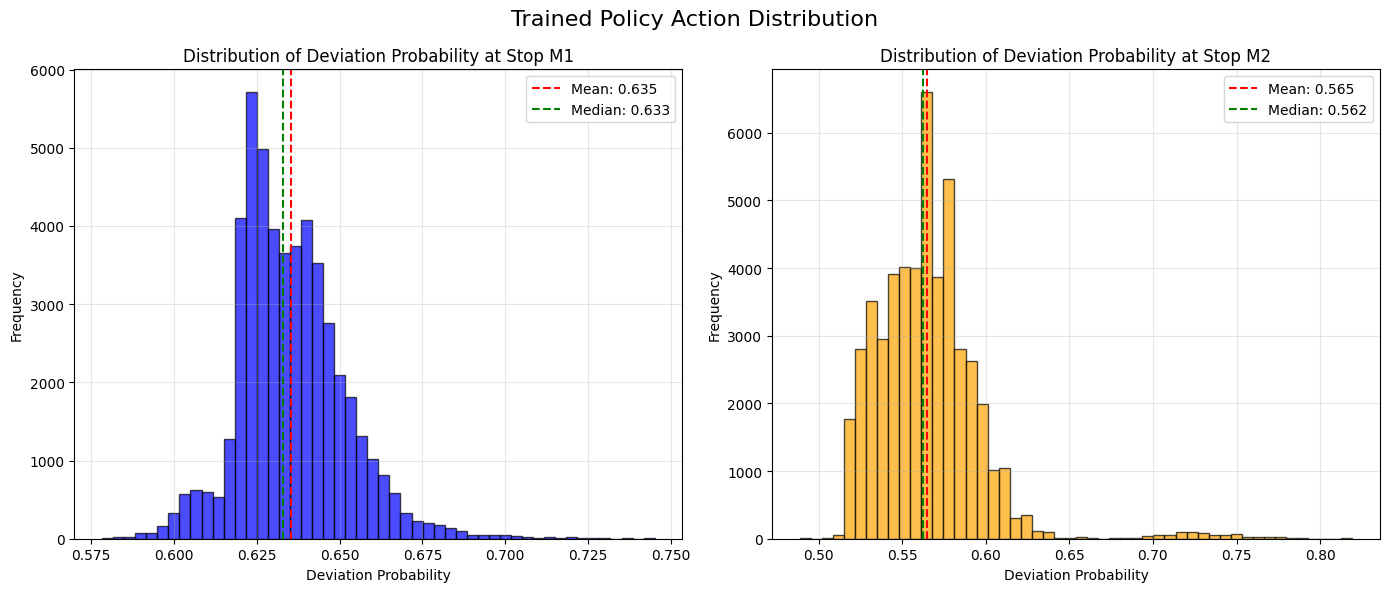


STATISTICAL COMPARISON:
T-test: statistic=435.2711, p-value=0.000000
KS-test: statistic=0.9170, p-value=0.000000
The means are significantly different (p < 0.05)


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def analyze_action_distributions(traj_list):
    """
    Analyze the distribution of values at index 0 and index 1 across all action columns
    """
    # Get all action columns (action_0, action_1, etc.)
    action_columns = [col for col in traj_list.columns if col.startswith('action_') and not col.startswith('direct_action_')]
    
    # Collect all values
    all_index_0_values = []
    all_index_1_values = []
    
    # Process each action column
    for action_col in action_columns:
        for idx, action_values in traj_list[action_col].items():
                all_index_0_values.append(action_values[0])
                all_index_1_values.append(action_values[1])
    
    # Convert to numpy arrays for easier analysis
    index_0_values = np.array(all_index_0_values)
    index_1_values = np.array(all_index_1_values)
    
    # Calculate statistics
    print("="*60)
    print("ACTION VALUE DISTRIBUTIONS:")
    print("="*60)
    print(f"Total samples: {len(index_0_values)}")
    print(f"Number of action columns: {len(action_columns)}")
    
    print(f"\nIndex 0 (First element) statistics:")
    print(f"  Mean: {np.mean(index_0_values):.4f}")
    print(f"  Std: {np.std(index_0_values):.4f}")
    print(f"  Min: {np.min(index_0_values):.4f}")
    print(f"  25th percentile: {np.percentile(index_0_values, 25):.4f}")
    print(f"  Median: {np.median(index_0_values):.4f}")
    print(f"  75th percentile: {np.percentile(index_0_values, 75):.4f}")
    print(f"  Max: {np.max(index_0_values):.4f}")
    
    print(f"\nIndex 1 (Second element) statistics:")
    print(f"  Mean: {np.mean(index_1_values):.4f}")
    print(f"  Std: {np.std(index_1_values):.4f}")
    print(f"  Min: {np.min(index_1_values):.4f}")
    print(f"  25th percentile: {np.percentile(index_1_values, 25):.4f}")
    print(f"  Median: {np.median(index_1_values):.4f}")
    print(f"  75th percentile: {np.percentile(index_1_values, 75):.4f}")
    print(f"  Max: {np.max(index_1_values):.4f}")
    
    # Plot distributions
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("Trained Policy Action Distribution", fontsize=16)
    # Histogram for index 0
    axes[0].hist(index_0_values, bins=50, alpha=0.7, color='blue', edgecolor='black')
    axes[0].set_title('Distribution of Deviation Probability at Stop M1', fontsize=12)
    axes[0].set_xlabel('Deviation Probability', fontsize=10)
    axes[0].set_ylabel('Frequency', fontsize=10)
    axes[0].axvline(np.mean(index_0_values), color='red', linestyle='--', label=f'Mean: {np.mean(index_0_values):.3f}')
    axes[0].axvline(np.median(index_0_values), color='green', linestyle='--', label=f'Median: {np.median(index_0_values):.3f}')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Histogram for index 1
    axes[1].hist(index_1_values, bins=50, alpha=0.7, color='orange', edgecolor='black')
    axes[1].set_title('Distribution of Deviation Probability at Stop M2', fontsize=12)
    axes[1].set_xlabel('Deviation Probability', fontsize=10)
    axes[1].set_ylabel('Frequency', fontsize=10)
    axes[1].axvline(np.mean(index_1_values), color='red', linestyle='--', label=f'Mean: {np.mean(index_1_values):.3f}')
    axes[1].axvline(np.median(index_1_values), color='green', linestyle='--', label=f'Median: {np.median(index_1_values):.3f}')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    # plt.title('Initial Behavioural Policy Action Distribution', fontsize=14)
    plt.tight_layout()
    plt.savefig("./exp_multi_epochs/changed_object2/action_distributions.png", dpi=300)
    plt.show()
    
    # Create combined histogram for comparison
    # plt.figure(figsize=(10, 6))
    # plt.hist(index_0_values, bins=50, alpha=0.5, label='Index 0', color='blue', density=True)
    # plt.hist(index_1_values, bins=50, alpha=0.5, label='Index 1', color='orange', density=True)
    # plt.xlabel('Value', fontsize=12)
    # plt.ylabel('Density', fontsize=12)
    # plt.title('Comparison of Index 0 vs Index 1 Distributions', fontsize=14)
    # plt.legend(fontsize=12)
    # plt.grid(True, alpha=0.3)
    # plt.tight_layout()
    # plt.savefig("./exp_multi_epochs/changed_object2/action_distributions_overlay.png", dpi=300)
    # plt.show()
    
    return index_0_values, index_1_values

# Usage
index_0_values, index_1_values = analyze_action_distributions(traj_list)

# Additional analysis - check if distributions are different
from scipy import stats

# Perform statistical tests
t_stat, t_pval = stats.ttest_ind(index_0_values, index_1_values)
ks_stat, ks_pval = stats.ks_2samp(index_0_values, index_1_values)

print("\n" + "="*60)
print("STATISTICAL COMPARISON:")
print("="*60)
print(f"T-test: statistic={t_stat:.4f}, p-value={t_pval:.6f}")
print(f"KS-test: statistic={ks_stat:.4f}, p-value={ks_pval:.6f}")
if t_pval < 0.05:
    print("The means are significantly different (p < 0.05)")
else:
    print("The means are not significantly different (p >= 0.05)")